## **IBM HR Analytics — Employee Attrition & Performance**

# **Project Objective**
In this project, I am performing an end-to-end data analytics workflow on the IBM HR Analytics Employee Attrition & Performance dataset using Python in  Google Colab. The objective is to understand employee demographics, job roles, satisfaction levels, and attrition patterns. I will follow a structured approach starting from data loading, then data cleaning and preprocessing, followed by exploratory data analysis (EDA), visualizations, and finally insight generation.


## **About the Dataset**
The IBM HR Analytics dataset contains employee records that capture various HR-related attributes such as age, department, job role, monthly income, job satisfaction, work-life balance, and whether the employee left the company (attrition). This dataset is widely used for understanding workforce analytics and building attrition prediction models.

##Project Structure




1.   Data Loading and Initial Overview
2.   Data Preprocessing


1.   Exploratory Data Analysis (EDA)
2.   Visualizations

1.   Insight Generation














##PHASE 1: Data Loading and Initial Overview
## Import Required Libraries
Before starting any data analysis project, I first import all the required Python libraries. These libraries provide the tools needed for data handling, numerical computation, and visualization.

Pandas is used to load and manipulate tabular data.

NumPy is used for numerical operations.

Matplotlib and Seaborn are used to create visualizations.
Importing all libraries at the beginning ensures consistency and avoids repetition later in the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")

All libraries imported successfully!


##Load the Dataset
The dataset fi loaded into a Pandas DataFrame named df. This will be the main object used for all further analysis.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the IBM HR Analytics dataset from CSV into a Pandas DataFrame
df = pd.read_csv("/content/drive/MyDrive/data analytics project/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully!
Dataset contains 1470 rows and 35 columns.


##Preview the Dataset — First 5 Rows

After loading the dataset, it is important to verify that the data has been read correctly. I display the first five rows of the dataset using df.head() to visually confirm the structure and values.

In [5]:
# Display the first 5 rows of the dataset
# This helps us quickly inspect column names and sample values
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Check Dataset Shape

In this step, I check how many rows and columns are present in the dataset.

Each row represents one employee record.

Each column represents an attribute related to the employee's profile, job role, or performance.

This step is important to confirm that the dataset has a sufficient number of records and features.

In [6]:
# df.shape returns a tuple of (number of rows, number of columns)
print("Dataset Shape:", df.shape)
print(f"\nThe dataset has {df.shape[0]} employee records and {df.shape[1]} attributes.")

Dataset Shape: (1470, 35)

The dataset has 1470 employee records and 35 attributes.


##Display All Column Names
I display all column names to understand what type of information is available in the dataset. This is an essential step before performing any analysis.

In [7]:
# df.columns returns the Index object containing all column names
print("Column Names in the Dataset:")
print(df.columns)

Column Names in the Dataset:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


##Column Descriptions
Before performing any analysis, it is very important to understand what each column represents. This ensures correct interpretation of results.
| Column                  | Type        | Description |
|--------------------------|-------------|-------------|
| Age                     | Numerical   | Age of the employee in years |
| Attrition               | Categorical | Whether the employee left (Yes/No) |
| BusinessTravel          | Categorical | Frequency of business travel |
| DailyRate               | Numerical   | Daily salary rate |
| Department              | Categorical | Department the employee belongs to |
| DistanceFromHome        | Numerical   | Distance from home to office (km) |
| Education               | Ordinal     | Education level (1–5 scale) |
| EducationField          | Categorical | Field of education |
| EmployeeCount           | Constant    | Always 1 — not useful for analysis |
| EmployeeNumber          | Numerical   | Unique employee ID |
| EnvironmentSatisfaction | Ordinal     | Satisfaction with work environment |
| Gender               | Categorical | Gender of the employee |
| HourlyRate           | Numerical   | Hourly salary rate |
| JobInvolvement       | Ordinal     | Level of job involvement (1–4) |
| JobLevel             | Ordinal     | Job level (1–5) |
| JobRole              | Categorical | Job role/title |
| JobSatisfaction      | Ordinal     | Satisfaction with job (1–4) |
| MaritalStatus        | Categorical | Marital status |
| MonthlyIncome        | Numerical   | Monthly salary |
| MonthlyRate          | Numerical   | Monthly rate |
| NumCompaniesWorked   | Numerical   | Number of companies previously worked at |
| Over18               | Constant    | Always 'Y' — not useful |
| OverTime             | Categorical | Whether employee works overtime (Yes/No) |
| PercentSalaryHike    | Numerical   | Last salary hike percentage |
| PerformanceRating         | Ordinal     | Performance rating (1–4) |
| RelationshipSatisfaction  | Ordinal     | Satisfaction with workplace relationships (1–4) |
| StandardHours             | Constant    | Always 80 — not useful |
| StockOptionLevel          | Ordinal     | Stock option level (0–3) |
| TotalWorkingYears         | Numerical   | Total years of work experience |
| TrainingTimesLastYear     | Numerical   | Number of trainings attended last year |
| WorkLifeBalance           | Ordinal     | Work-life balance rating (1–4) |
| YearsAtCompany            | Numerical   | Years spent at IBM |
| YearsInCurrentRole        | Numerical   | Years in current job role |
| YearsSinceLastPromotion   | Numerical   | Years since last promotion |
| YearsWithCurrManager      | Numerical   | Years working with current manager |

##Dataset Info — Data Types and Non-Null Counts
I use df.info() to get a concise summary of the dataset. This shows the data type of each column, the number of non-null values, and total memory usage.

In [8]:
# df.info() provides a quick overview of data types and null value counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

##Statistical Summary of Numerical Columns
Here, I generate a statistical summary of numerical columns using df.describe(). This provides insights into the mean, minimum, maximum, standard deviation, and distribution of values. This summary helps identify potential outliers and understand the range of each numerical feature.

In [9]:
# df.describe() generates descriptive statistics for all numerical columns
# It shows count, mean, std, min, 25th percentile, median, 75th percentile, and max
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


##PHASE 2: Data Preprocessing
Data preprocessing is one of the most critical steps in any data analysis project. Raw data often contains errors, missing values, duplicates, or inappropriate data types. In this phase, I will clean and prepare the data to ensure accurate and meaningful analysis.


## Check for Missing Values
I check for missing values in each column. Missing data can distort analysis results. If any column has missing values, I will decide whether to fill them (imputation) or drop them based on the context.

In [10]:
# df.isnull().sum() counts the number of missing (NaN) values in each column
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


##Check for and Remove Duplicate Records
Duplicate rows can lead to biased analysis results by giving extra weight to certain records. I check if any employee records appear more than once in the dataset and remove them if found.

In [11]:
# df.duplicated().sum() counts the total number of duplicate rows in the dataset
df.duplicated().sum()


np.int64(0)

##Remove Constant / Useless Columns
Some columns in this dataset contain only a single constant value across all rows. Such columns do not provide any useful information for analysis and should be dropped to reduce noise

* EmployeeCount — Always equals 1

* StandardHours — Always equals 80

* Over18 — Always equals 'Y'

Removing these columns makes the dataset lighter and the analysis more focused.

In [12]:
# Drop columns that have only one unique value — they add no analytical value
df = df.drop(columns= ['EmployeeCount', 'StandardHours', 'Over18'])


##Convert Categorical Columns to Correct Data Types
Some columns that contain categorical labels (like 'Attrition', 'OverTime') are stored as object (string) type. I convert 'Attrition' and 'OverTime' to binary numerical values (0/1) to enable correlation analysis and easier groupby operations.

In [13]:
# Convert 'Attrition' from Yes/No string to binary integer values
# Yes = 1 means the employee left the company; No = 0 means they stayed
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Convert 'OverTime' from Yes/No string to binary integer values
# Yes = 1 means the employee works overtime; No = 0 means they do not
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print(df['Attrition'].value_counts())
print(df['OverTime'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64
OverTime
0    1054
1     416
Name: count, dtype: int64


##Feature Engineering — Create 7 New Analytical Columns

Feature engineering involves creating new columns from existing data to extract more meaningful insights. I will create several derived columns that will be very useful in the EDA and visualization phases

##Age Group
Categorize employees into meaningful age brackets for demographic analysis. This allows us to compare attrition rates and satisfaction across age groups.

In [14]:
# Define a custom function with any logic you want
def categorize_age(age):
    if age < 25:
        return 'Gen Z (Under 25)'
    elif age < 35:
        return 'Young Millennial (25-34)'
    elif age < 45:
        return 'Senior Millennial (35-44)'
    elif age < 55:
        return 'Gen X (45-54)'
    else:
        return 'Baby Boomer (55+)'

# Apply the function to every row of the Age column
df['AgeCategory'] = df['Age'].apply(categorize_age)

print(df['AgeCategory'].value_counts())

AgeCategory
Young Millennial (25-34)     554
Senior Millennial (35-44)    505
Gen X (45-54)                245
Gen Z (Under 25)              97
Baby Boomer (55+)             69
Name: count, dtype: int64


##Income Level
Categorize employees into income brackets based on their MonthlyIncome. This helps compare attrition, performance, and satisfaction across income levels.

In [15]:
# Same approach for Income with business-relevant labels
def categorize_income(income):
    if income < 3000:
        return 'Entry Pay (<3K)'
    elif income < 7000:
        return 'Mid Pay (3K-7K)'
    elif income < 12000:
        return 'Senior Pay (7K-12K)'
    else:
        return 'Executive Pay (12K+)'

df['IncomeLevel'] = df['MonthlyIncome'].apply(categorize_income)

print(df['IncomeLevel'].value_counts())

IncomeLevel
Mid Pay (3K-7K)         640
Entry Pay (<3K)         395
Senior Pay (7K-12K)     240
Executive Pay (12K+)    195
Name: count, dtype: int64


##Experience Level
Categorize employees by their total working years to reflect career stage. This helps understand which experience group has higher attrition risk.

In [16]:
# Define a function to assign experience level based on TotalWorkingYears
def experience_level(years):
    if years <= 3:
        return 'Entry Level (0-3 yrs)'
    elif years <= 10:
        return 'Mid Level (4-10 yrs)'
    elif years <= 20:
        return 'Senior Level (11-20 yrs)'
    else:
        return 'Expert Level (20+ yrs)'

# Apply the function to each row using the TotalWorkingYears column
df['ExperienceLevel'] = df['TotalWorkingYears'].apply(experience_level)
print(df['ExperienceLevel'].value_counts())

ExperienceLevel
Mid Level (4-10 yrs)        758
Senior Level (11-20 yrs)    340
Expert Level (20+ yrs)      207
Entry Level (0-3 yrs)       165
Name: count, dtype: int64


##Composite Satisfaction Score

Create a composite satisfaction score by averaging four satisfaction-related columns: JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, and WorkLifeBalance. This gives a holistic view of employee well-being in a single metric.

In [17]:
# Calculate the row-wise mean across the four satisfaction columns
# axis=1 means we compute across columns (horizontally) for each employee row
df['CompositeSatisfaction'] = df[['JobSatisfaction', 'EnvironmentSatisfaction',
                                   'RelationshipSatisfaction', 'WorkLifeBalance']].mean(axis=1).round(2)
print(df['CompositeSatisfaction'].describe())

count    1470.000000
mean        2.730952
std         0.505815
min         1.000000
25%         2.500000
50%         2.750000
75%         3.000000
max         4.000000
Name: CompositeSatisfaction, dtype: float64


##Tenure Category
Classify employees based on how long they have been with IBM. This helps identify if newer or older employees are more likely to leave.

In [18]:
# Define a function to classify employees based on their years at the company
def tenure_category(years):
    if years <= 2:
        return 'New Hire (0-2 yrs)'
    elif years <= 5:
        return 'Established (3-5 yrs)'
    elif years <= 10:
        return 'Loyal (6-10 yrs)'
    else:
        return 'Veteran (10+ yrs)'

# Apply the function to the YearsAtCompany column
df['TenureCategory'] = df['YearsAtCompany'].apply(tenure_category)
print(df['TenureCategory'].value_counts())

TenureCategory
Loyal (6-10 yrs)         448
Established (3-5 yrs)    434
New Hire (0-2 yrs)       342
Veteran (10+ yrs)        246
Name: count, dtype: int64


##Promotion Gap Category
Classify employees based on how long it has been since their last promotion. Employees who have not received a promotion in a long time may be dissatisfied.

In [19]:
# Define a function to classify the promotion gap into four categories
def promotion_gap(years):
    if years == 0:
        return 'Recently Promoted'
    elif years <= 3:
        return 'Promoted 1-3 Yrs Ago'
    elif years <= 7:
        return 'Promoted 4-7 Yrs Ago'
    else:
        return 'Promotion Overdue (7+ Yrs)'

# Apply the function to the YearsSinceLastPromotion column
df['PromotionGap'] = df['YearsSinceLastPromotion'].apply(promotion_gap)
print(df['PromotionGap'].value_counts())

PromotionGap
Recently Promoted             581
Promoted 1-3 Yrs Ago          568
Promoted 4-7 Yrs Ago          214
Promotion Overdue (7+ Yrs)    107
Name: count, dtype: int64


##High Attrition Risk Flag
Create a risk flag column based on three factors associated with attrition: working overtime, low job satisfaction (≤2), and poor work-life balance (≤2). An employee is flagged as high risk if they meet at least 2 of these 3 conditions.                                                                                                                                                     
np.where() is the simplest and fastest method for a basic Yes/No risk flag based on a single combined condition.

In [20]:
# np.where(condition, value_if_true, value_if_false)
# This creates a clean binary flag in one single line

df['RiskFlag_where'] = np.where(
    (df['OverTime'] == 1) &
    (df['JobSatisfaction'] <= 2) &
    (df['WorkLifeBalance'] <= 2),
    'High Risk',       # Assigned when ALL three conditions are True
    'Low Risk'         # Assigned when any condition is False
)

print("Risk Flag Distribution (np.where):")
print(df['RiskFlag_where'].value_counts())

Risk Flag Distribution (np.where):
RiskFlag_where
Low Risk     1431
High Risk      39
Name: count, dtype: int64


##PHASE 3: Exploratory Data Analysis (EDA) & Visualizations

In this phase, I perform a thorough exploration of the dataset through descriptive statistics, group-based analysis, and visualizations. I cover univariate, bivariate, and multivariate analysis

##Univariate Analysis

Attrition Count

This visualization shows the distribution of employees who left the company and those who stayed.

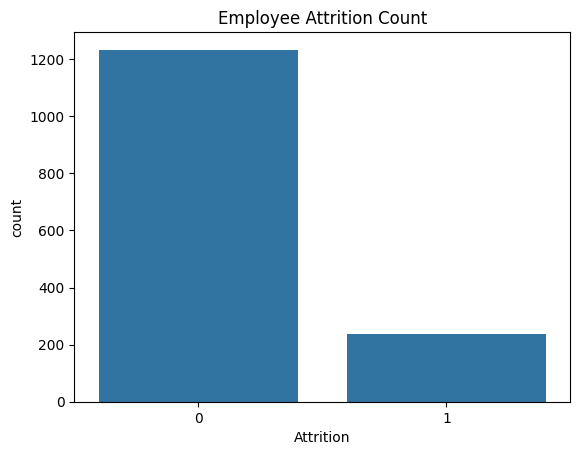

In [21]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()

Age Distribution

This histogram shows the age distribution of employees in the organization.

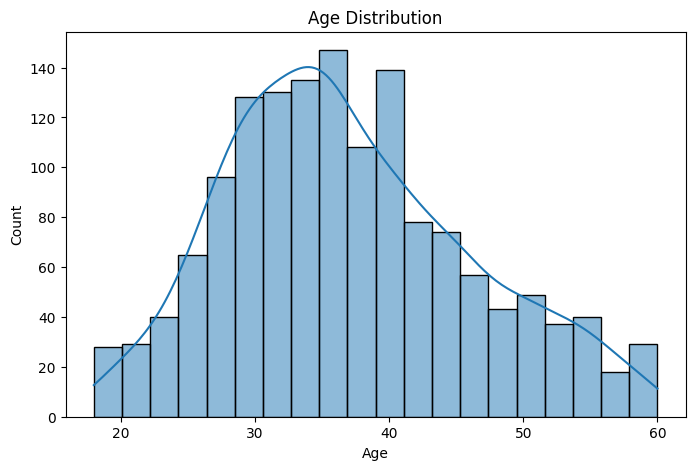

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

##Bivariate Analysis

Attrition vs Overtime

This chart compares employee attrition with overtime status to understand whether overtime influences attrition.

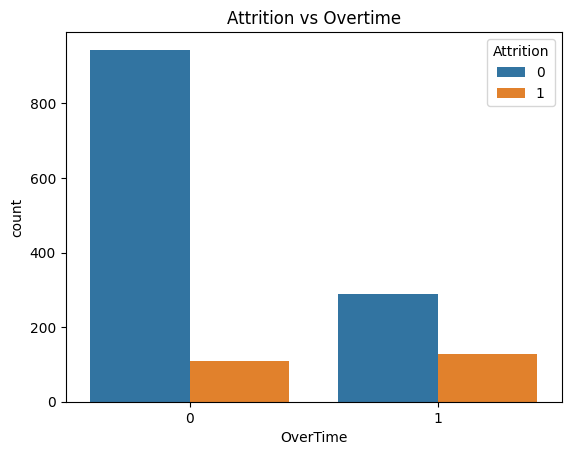

In [23]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition vs Overtime")
plt.show()

Monthly Income by Department

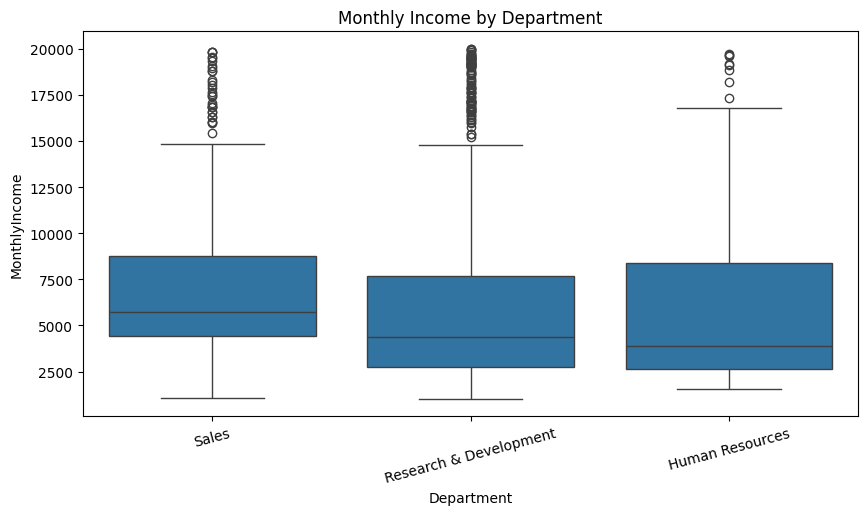

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Department', y='MonthlyIncome', data=df)
plt.title("Monthly Income by Department")
plt.xticks(rotation=15)
plt.show()

##Multivariate Analysis

Multivariate analysis studies relationships among more than two variables at the same time.

Attrition Analysis based on Age, Income, and Overtime

This scatter plot analyzes the relationship between employee age, monthly income, and overtime status with attrition.

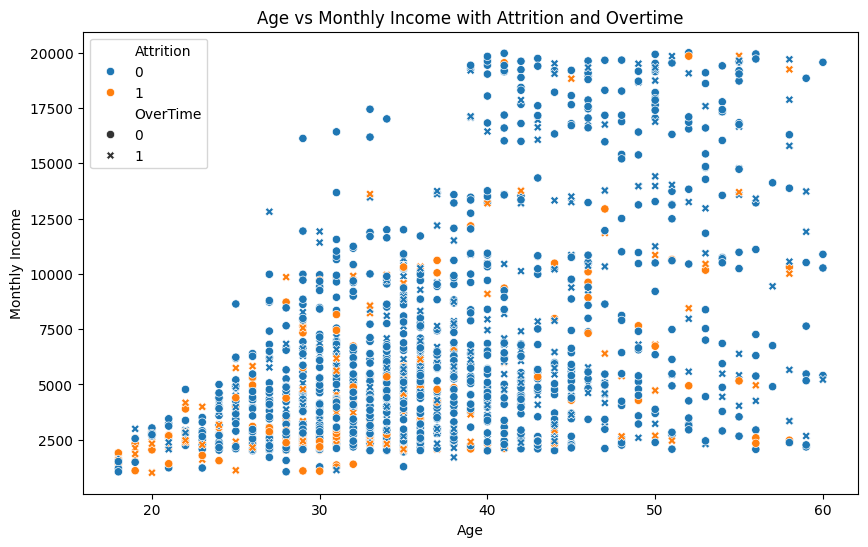

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Age',
    y='MonthlyIncome',
    hue='Attrition',
    style='OverTime',
    data=df
)

plt.title("Age vs Monthly Income with Attrition and Overtime")
plt.xlabel("Age")
plt.ylabel("Monthly Income")

plt.show()

Pair Plot of Important Numerical Variables

This pair plot helps analyze relationships among important numerical variables and attrition categories.

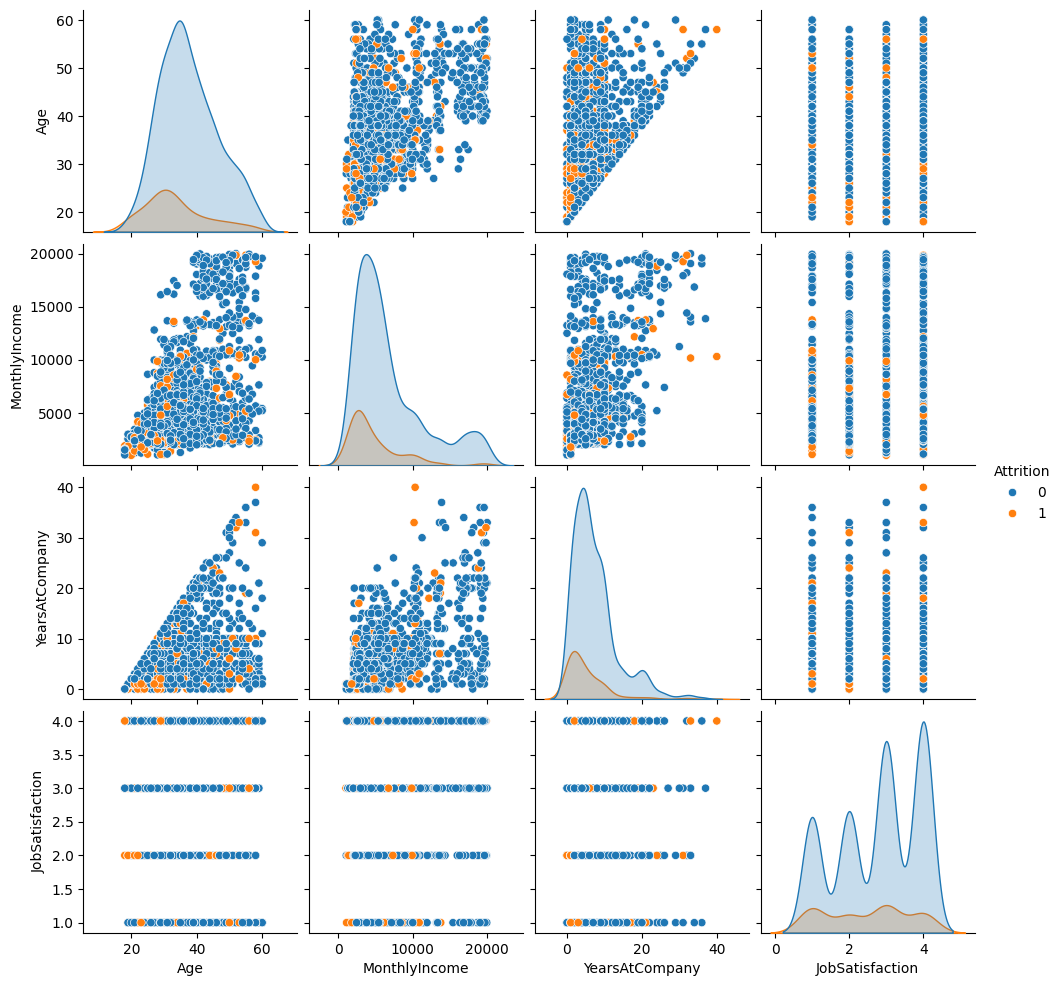

In [26]:
selected_data = df[[
    'Age',
    'MonthlyIncome',
    'YearsAtCompany',
    'JobSatisfaction',
    'Attrition'
]]

sns.pairplot(
    selected_data,
    hue='Attrition'
)

plt.show()

Violin Plot of Monthly Income by Attrition and Gender

This violin plot shows salary distribution patterns based on attrition and gender.

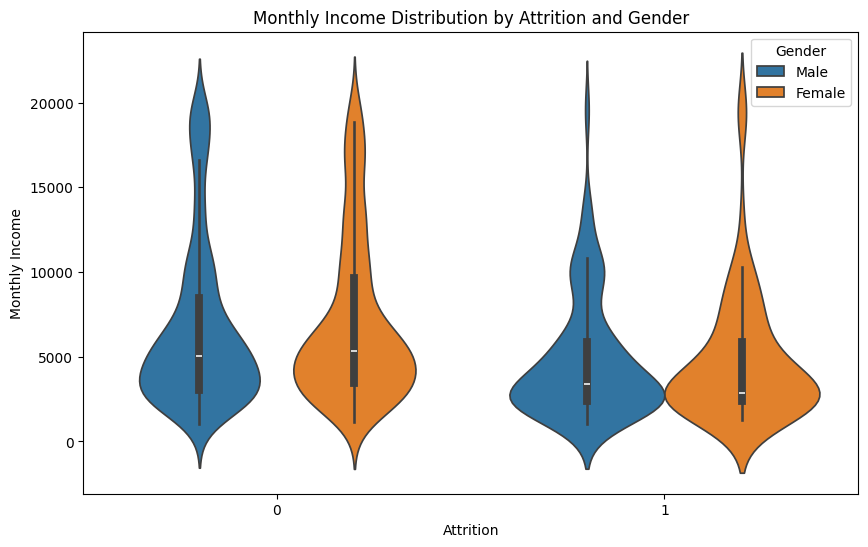

In [27]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Attrition',
    y='MonthlyIncome',
    hue='Gender',
    data=df
)

plt.title("Monthly Income Distribution by Attrition and Gender")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset.

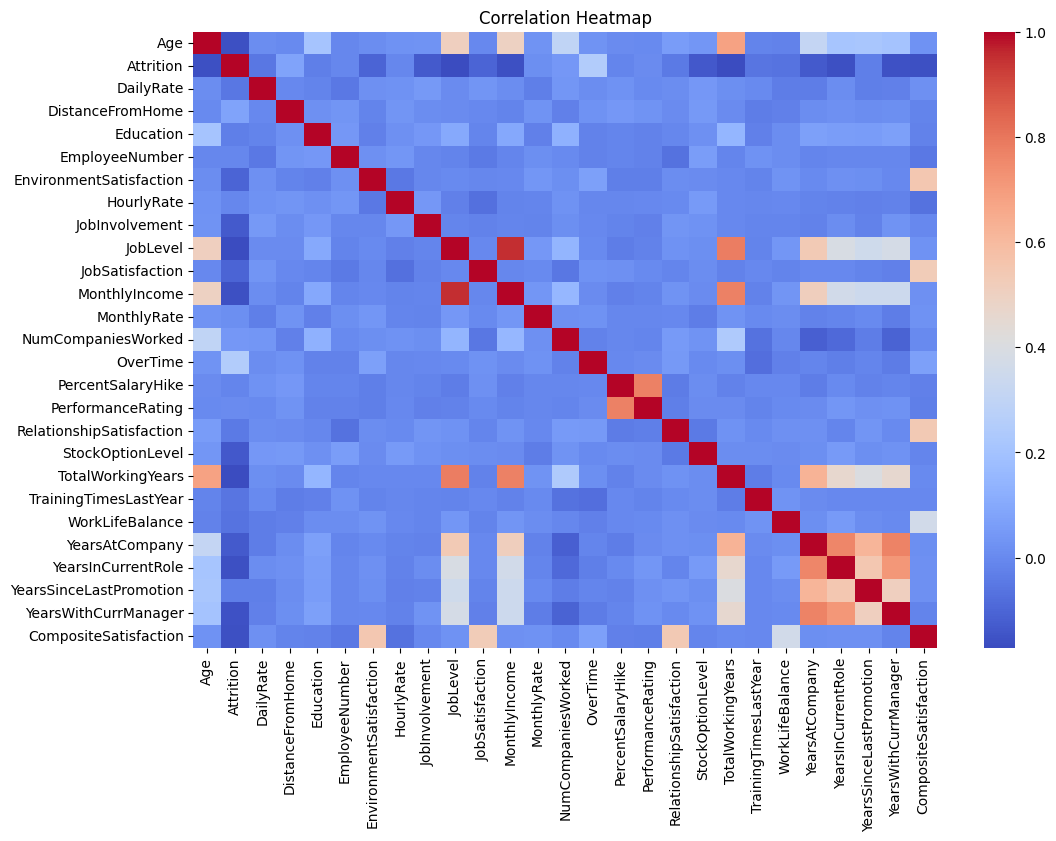

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

GroupBy Analysis

GroupBy analysis helps summarize data based on categories such as department or job role.

In [26]:
df.groupby('Department')['MonthlyIncome'].mean()

,MonthlyIncome
Department,
Human Resources,6654.507937
Research & Development,6281.252862
Sales,6959.172646


In [27]:
df.groupby('JobRole')['JobSatisfaction'].mean()

,JobSatisfaction
JobRole,
Healthcare Representative,2.786260
Human Resources,2.557692
Laboratory Technician,2.691120
Manager,2.705882
Manufacturing Director,2.682759
Research Director,2.700000
Research Scientist,2.773973
Sales Executive,2.754601
Sales Representative,2.734940


##Pivot Table Analysis

Average Monthly Income by Department

This pivot table shows the average monthly income of employees across different departments.

In [28]:
pivot_income = pd.pivot_table(
    df,
    values='MonthlyIncome',
    index='Department',
    aggfunc='mean'
)

pivot_income

,MonthlyIncome
Department,
Human Resources,6654.507937
Research & Development,6281.252862
Sales,6959.172646


Attrition Count by Department

This pivot table shows the number of employees who left and stayed in each department.

In [30]:
pivot_attrition = pd.pivot_table(
    df,
    values='EmployeeNumber',
    index='Department',
    columns='Attrition',
    aggfunc='count'
)

pivot_attrition

Attrition,0,1
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


## Other Visualizations

Gender Distribution Pie Chart

This pie chart represents the proportion of male and female employees in the dataset.

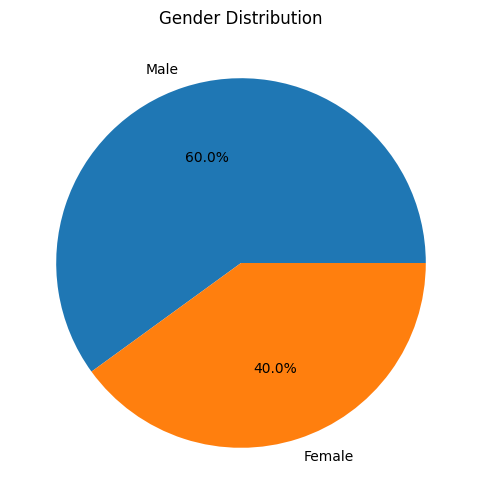

In [31]:
gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.show()

Monthly Income Distribution

This histogram shows the distribution of monthly income among employees.

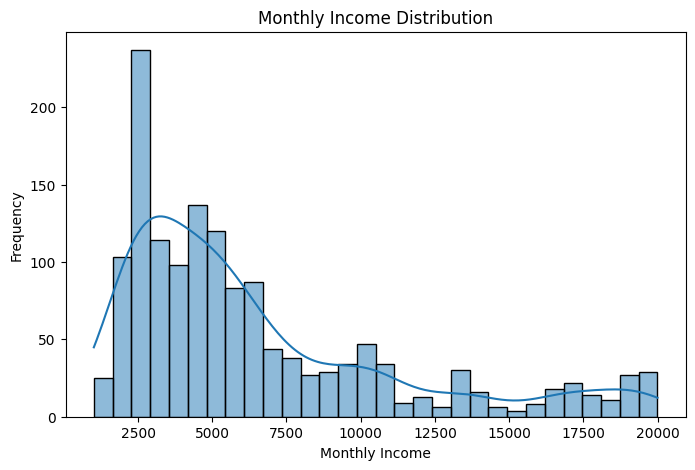

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'], bins=30, kde=True)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

Education Field Distribution

This chart shows the number of employees from different education fields.

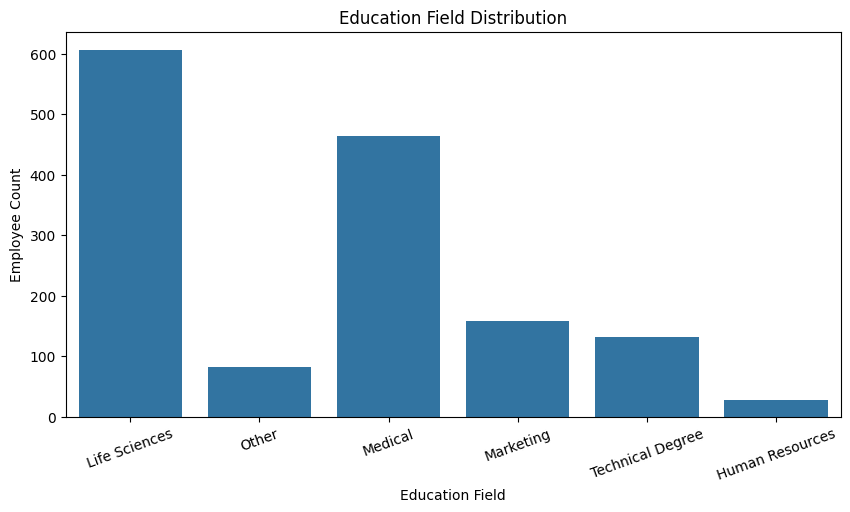

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(x='EducationField', data=df)

plt.title("Education Field Distribution")
plt.xlabel("Education Field")
plt.ylabel("Employee Count")

plt.xticks(rotation=20)

plt.show()

Scatter Plot: Age vs Monthly Income

This scatter plot analyzes the relationship between employee age and monthly income.

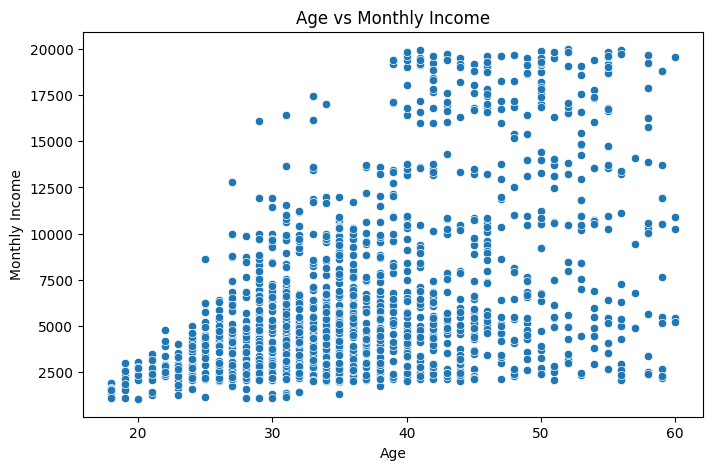

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='MonthlyIncome', data=df)

plt.title("Age vs Monthly Income")
plt.xlabel("Age")
plt.ylabel("Monthly Income")

plt.show()

Years at Company Distribution

This histogram shows how long employees have worked in the company.

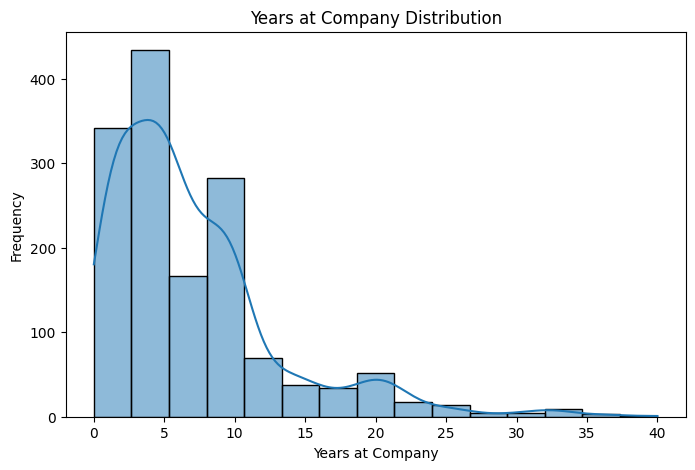

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df['YearsAtCompany'], bins=15, kde=True)

plt.title("Years at Company Distribution")
plt.xlabel("Years at Company")
plt.ylabel("Frequency")

plt.show()

Heatmap of Attrition by Job Role and Overtime

This heatmap analyzes employee attrition across job roles and overtime status.

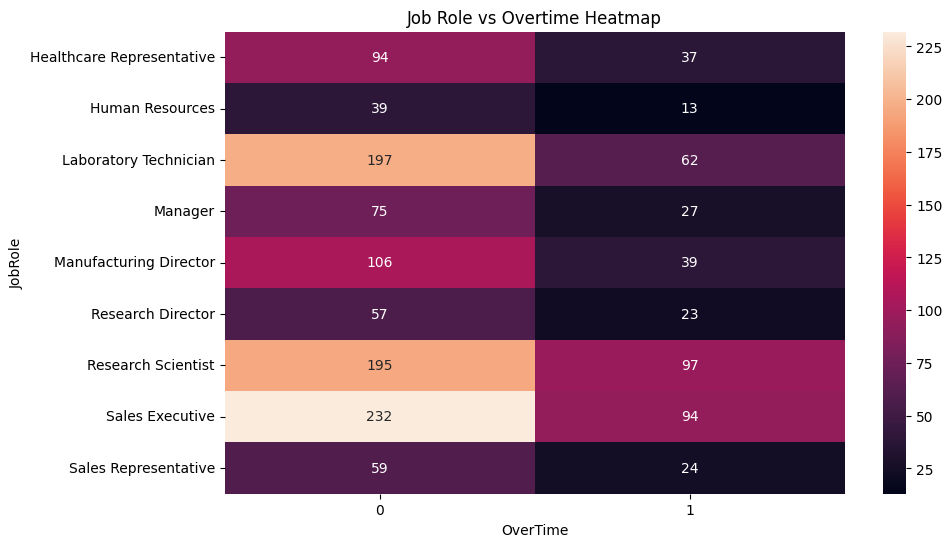

In [37]:
pivot = pd.pivot_table(
    df,
    values='EmployeeNumber',
    index='JobRole',
    columns='OverTime',
    aggfunc='count'
)

plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, fmt='.0f')

plt.title("Job Role vs Overtime Heatmap")

plt.show()

Average Income by Education Level

This line chart shows how employee income changes with education level.

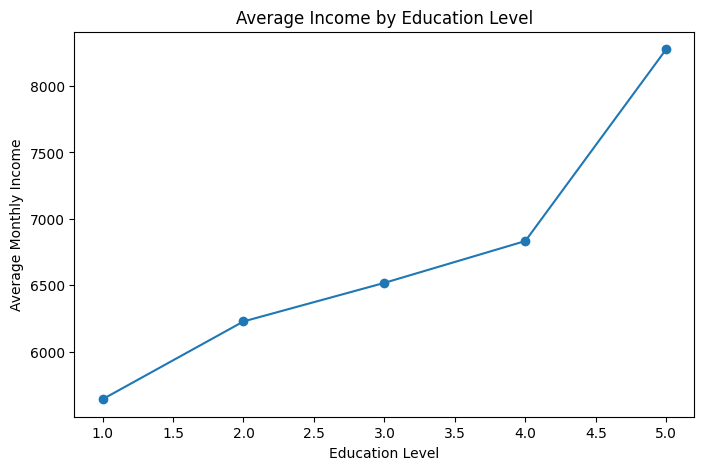

In [38]:
education_income = df.groupby('Education')['MonthlyIncome'].mean()

plt.figure(figsize=(8,5))

plt.plot(education_income.index, education_income.values, marker='o')

plt.title("Average Income by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Monthly Income")

plt.show()

Department-wise Average Performance Rating

This visualization shows the distribution of employee performance ratings.

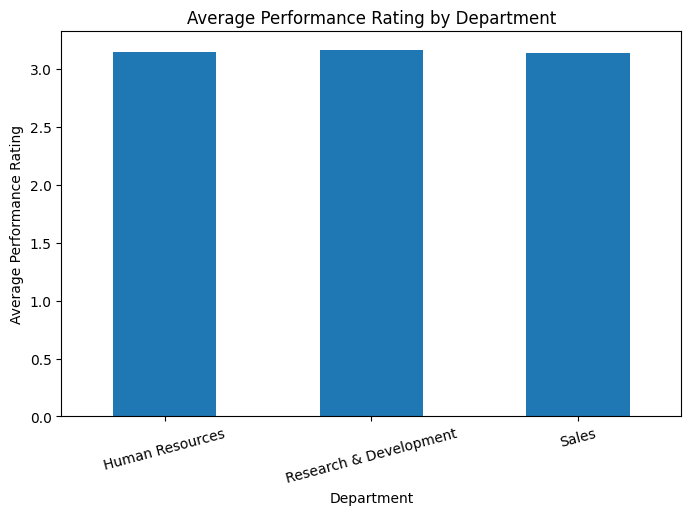

In [39]:
performance = df.groupby('Department')['PerformanceRating'].mean()

plt.figure(figsize=(8,5))

performance.plot(kind='bar')

plt.title("Average Performance Rating by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Rating")

plt.xticks(rotation=15)

plt.show()

Facet Grid Analysis of Attrition by Department

This Facet Grid visualization compares age and monthly income distribution across departments based on attrition.

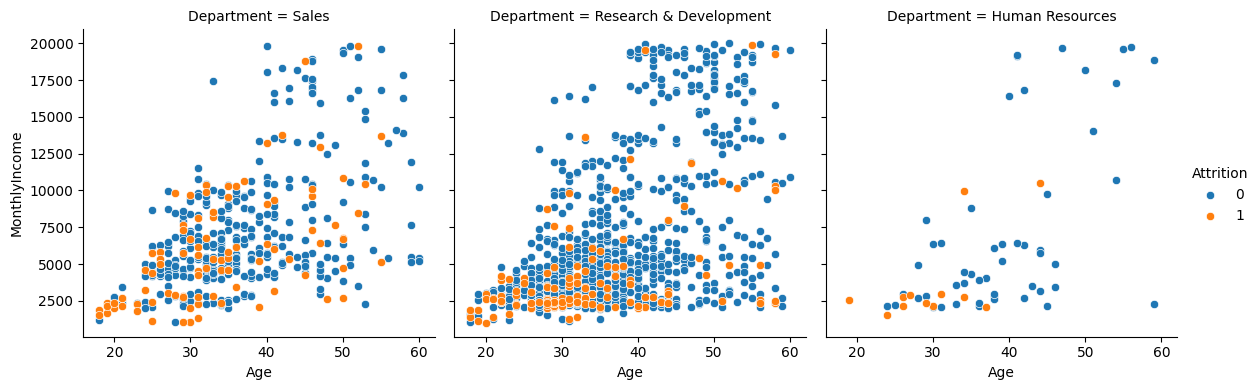

In [28]:
g = sns.FacetGrid(
    df,
    col='Department',
    hue='Attrition',
    height=4
)

g.map(
    sns.scatterplot,
    'Age',
    'MonthlyIncome'
)

g.add_legend()

plt.show()

##PHASE 4: Insight Generation and Summary

##Key Insights
1. Attrition Rate

The overall employee attrition rate in the dataset is approximately 16.1%, meaning roughly 1 in 6 employees left the organization.

2. Age and Attrition

Younger employees (age group 18–30) show the highest attrition rates. Employees tend to stabilize after the age of 35.
The average age of employees who left is lower than those who stayed, suggesting early-career dissatisfaction.

3. Job Role and Department

Sales Representatives and Laboratory Technicians have the highest attrition counts.
The Sales department has the highest attrition rate among all departments, followed by Human Resources.
Research & Development has the largest workforce but relatively better retention.

4. Income and Attrition

Employees who left had a significantly lower average monthly income compared to those who stayed.
Attrition is concentrated in the lower salary slab category, indicating compensation is a key driver.

5. Job Satisfaction and Environment

Employees who rated Job Satisfaction as 1 (Low) showed much higher attrition.
Similarly, low Environment Satisfaction and Relationship Satisfaction scores correlate strongly with employees leaving.

6. Overtime

Employees who work overtime are far more likely to leave — nearly 30% of overtime workers show attrition vs. ~10% of non-overtime workers.
This is one of the strongest predictors of attrition in the dataset.

7. Work-Life Balance

Employees rating their work-life balance as "Bad" (1) are significantly more prone to leaving.

8. Years at Company and Promotion

Employees with 0–2 years at the company show the highest attrition — onboarding and early engagement are critical.
Employees who have gone many years without a promotion also show elevated attrition risk.

9. Distance from Home

Employees living far from the office show slightly higher attrition, suggesting commute burden is a contributing factor.

10. Marital Status

Single employees have the highest attrition rate compared to married or divorced employees, possibly due to greater mobility and fewer personal anchors.



##Summary
This project performs an end-to-end Exploratory Data Analysis (EDA) on the IBM HR Analytics Employee Attrition & Performance dataset. The dataset contains 1,470 employee records with 35 features covering demographics, job characteristics, compensation, satisfaction scores, and attrition labels.
The analysis involved:

1. Data Cleaning: Checking for null values, removing redundant columns (e.g.,
EmployeeCount, Over18, StandardHours), and verifying data types.

2. Univariate Analysis: Distribution of attrition, age, monthly income, job roles, and departments.

3. Bivariate Analysis: Exploring relationships between attrition and key variables such as overtime, salary, job satisfaction, and years at the company.

4. Correlation Analysis: Using a heatmap to identify numerical features most correlated with attrition.

5. Visualization: Bar charts, count plots, box plots, violin plots, and heatmaps were used to communicate findings clearly.

The analysis reveals that attrition is not caused by a single factor but by a combination of low compensation, poor satisfaction, high overtime, and limited career growth. These insights lay the foundation for targeted, data-driven HR interventions.

##Business Recommendations

1. Address Overtime Policies

Strictly monitor and limit mandatory overtime. Introduce compensatory time-off or additional pay for employees regularly working beyond hours. Overtime is one of the strongest attrition signals found in this dataset.

2. Competitive Compensation Review

Conduct a salary benchmarking exercise, especially for Sales Representatives and Laboratory Technicians. Employees in the lowest salary band are at highest risk — targeted pay revisions for this group can significantly reduce attrition.

3. Strengthen Early-Career Engagement

Focus retention efforts on employees with less than 2 years of tenure. Implement structured onboarding programs, mentorship, and 90-day/6-month check-ins to improve early engagement.

4. Improve Job and Environment Satisfaction

Regularly conduct employee satisfaction surveys. Departments with low job and environment satisfaction scores should be prioritized for management interventions, team restructuring, or culture improvement programs.

5. Career Development and Promotions

Employees who feel stuck in their roles are more likely to leave. Create clear promotion pathways and ensure employees are recognized and advanced at regular intervals. Flag employees who haven't had a promotion in 4+ years for career development conversations.

6. Focus on the Sales Department

The Sales department shows disproportionately high attrition. Consider reviewing sales targets, work pressure, incentive structures, and team culture in this department specifically.

7. Work-Life Balance Initiatives

Introduce flexible working arrangements, remote work options, and wellness programs, particularly for employees reporting poor work-life balance. This also addresses the commute burden for employees living far from the office.

8. Retention Programs for Single Employees

Since single employees show higher attrition, consider social engagement programs, team-building activities, and community-building within the workplace to improve belongingness and reduce voluntary exits.



